# E12b · Pemeriksaan lanjutan varian anomali STMAC

Notebook E12 menunjukkan bahwa varian anomali (solver gabungan pada selisih terhadap klimatologi
stasiun, dengan ridge) paling akurat pada data 1999. Notebook ini melengkapi dua hal sebelum varian
tersebut dipakai sebagai STMAC di naskah:

1. ablasi sheaf di dalam varian anomali (trivial lawan longitude, 20 realisasi),
2. prosedur pemilihan $(r,\gamma)$ lewat validasi silang blok yang dijalankan ulang pada setiap
   jaringan satelit 2019 (N = 11, 25, 50), lalu dievaluasi pada 10 realisasi.

Bagian terakhir menyusun gambar dan tabel untuk naskah dari berkas `E12_`. Notebook ini membutuhkan
hasil E12 di folder `results/`.

In [1]:
import sys, json, time, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12.5,
    "xtick.labelsize": 11.5, "ytick.labelsize": 11.5, "legend.fontsize": 11,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
HERE = Path.cwd().resolve()
for p in (HERE, HERE.parent, HERE / "notebooks"):
    if (p / "stmac_joint.py").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
import stmac_joint as sj
import stmac_rerun_utils as ru

DATA = ru.locate("data", "multistation_1999_cleaned.parquet")
ROOT = DATA.parent
RES = ROOT / "results"
for p in (ROOT, ROOT / "notebooks"):
    if p.exists() and str(p) not in sys.path:
        sys.path.append(str(p))
try:
    ss_proj = importlib.import_module("stmac_scalable")
except Exception:
    ss_proj = None
build_graph = ss_proj.build_graph if (ss_proj is not None and hasattr(ss_proj, "build_graph")) else ru.build_graph

def idn(x, nd=1):
    s = f"{x:,.{nd}f}"
    return s.replace(",", "_").replace(".", ",").replace("_", ".")

need = ["E12_anomaly_eval.csv", "E12_anomaly_cv.csv", "E12_anomaly_summary.csv", "E12_E7J_raw.csv",
        "E12_TF_heldout_summary.csv", "E12_TF_heldout_raw.csv", "E12_E11J_raw.csv", "E11_raw.csv"]
missing = [f for f in need if not (RES / f).exists()]
assert not missing, f"jalankan E12 dahulu; berkas belum ada: {missing}"

MDV_HW, SEL_SEED, CV_HIDE_FRAC = 15, 101, 0.05
AN_GRID = [(r, g) for r in (10.0, 100.0, 1000.0, 10000.0) for g in (0.0, 0.3, 1.0, 3.0, 10.0, 30.0)]
ANCV = pd.read_csv(RES / "E12_anomaly_cv.csv")
an_cv = ANCV[ANCV.variant == "anomaly"]
R_AN, G_AN = (float(v) for v in an_cv.groupby(["ratio", "ridge"]).cv_rmse.mean().idxmin())

multi = pd.read_parquet(DATA / "multistation_1999_cleaned.parquet")
STATIONS = json.load(open(DATA / "stations.json")); CODES = list(STATIONS)
multi = multi[CODES]
LAT = np.array([STATIONS[c]["lat"] for c in CODES], float)
LON = np.array([STATIONS[c]["lon"] for c in CODES], float)
U_ALL = multi.to_numpy().T.astype(float); N, T = U_ALL.shape; IDX = multi.index
DELTA = (LON - LON.mean()) / 15 * 60 / 5
L_G = np.load(DATA / "graph_L.npy"); L_TIME = sj.build_temporal_smoothness(T)
DAYTIME = (IDX.hour.values >= 8) & (IDX.hour.values <= 16)
LABEL = dict(sj.BLOCK_SPECS)
print(f"Pasangan varian anomali dari E12: r = {R_AN:g}, ridge = {G_AN:g}")

Pasangan varian anomali dari E12: r = 1000, ridge = 3


## 1. Ablasi sheaf di dalam varian anomali

Kita menjalankan varian anomali dengan sheaf trivial pada 20 mask E7 yang sama, lalu
membandingkannya dengan versi sheaf longitude dari `E12_anomaly_eval.csv`.

In [2]:
OUT1 = RES / "E12b_anomaly_trivial.csv"
rows = pd.read_csv(OUT1).to_dict("records") if OUT1.exists() else []
done = {(int(r["seed"]), int(r["block_len"])) for r in rows}
for seed in range(20):
    for bl, lab in sj.BLOCK_SPECS:
        if (seed, bl) in done:
            continue
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        C = ru.mdv_field(U_ALL, mask, IDX, MDV_HW)
        U_t = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, None, None, R_AN, 1.0, ridge=G_AN, prior=C)
        rows.append({"seed": seed, "block_len": bl, "block_label": lab,
                     "rmse_anomaly_trivial": sj.rmse(U_ALL, U_t, ev)})
    ru.atomic_csv(pd.DataFrame(rows), OUT1)
AB = (pd.DataFrame(rows).drop(columns="block_label")
      .merge(pd.read_csv(RES / "E12_anomaly_eval.csv"), on=["seed", "block_len"])
      .rename(columns={"rmse_anomaly": "rmse_anomaly_longitude"}))
T_ab = ru.paired_family(AB, "anomaly_trivial", "anomaly_longitude")
ru.atomic_csv(T_ab, RES / "E12b_sheaf_ablation_tests.csv")
d_ab = (AB.rmse_anomaly_trivial - AB.rmse_anomaly_longitude).to_numpy()
p_ab = stats.wilcoxon(AB.rmse_anomaly_trivial, AB.rmse_anomaly_longitude).pvalue
print(T_ab[["label", "mean_diff", "ci_lo", "ci_hi", "wins_b", "n", "p_holm"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

 label  mean_diff    ci_lo    ci_hi  wins_b  n   p_holm
30 min      1.592    1.293    1.892      20 20    0.000
   2 h      1.057    0.674    1.440      19 20    0.000
   6 h      0.299    0.148    0.451      18 20    0.000
  12 h      0.045   -0.054    0.145      11 20    1.000
 1 day      0.104    0.021    0.187      12 20    0.077
 3 day     -0.013   -0.044    0.018       9 20    1.000
 7 day     -0.006   -0.030    0.018       9 20    1.000


In [3]:
print("INTERPRETASI ABLASI SHEAF")
print("=" * 88)
sig = T_ab[(T_ab.mean_diff > 0) & (T_ab.p_holm < 0.05)]
ns = T_ab[T_ab.p_holm >= 0.05]
print(f"- Sheaf longitude menurunkan RMSE varian anomali secara signifikan di "
      f"{', '.join(sig.label) if len(sig) else 'tidak ada blok'} "
      f"({', '.join(idn(v, 2) for v in sig.mean_diff)} W/m2).")
print(f"- Tidak berbeda signifikan di {', '.join(ns.label) if len(ns) else 'tidak ada blok'}.")
print(f"- Gabungan {len(d_ab)} pasangan: rata-rata {idn(d_ab.mean(), 2)} W/m2, longitude menang "
      f"{int((d_ab > 0).sum())}/{len(d_ab)}, p = {p_ab:.1e}.")

INTERPRETASI ABLASI SHEAF
- Sheaf longitude menurunkan RMSE varian anomali secara signifikan di 30 min, 2 h, 6 h (1,59, 1,06, 0,30 W/m2).
- Tidak berbeda signifikan di 12 h, 1 day, 3 day, 7 day.
- Gabungan 140 pasangan: rata-rata 0,44 W/m2, longitude menang 98/140, p = 1.0e-11.


## 2. Pemilihan $(r,\gamma)$ per jaringan satelit

Prosedur pemilihan sama dengan E12 bagian 4b: satu mask dasar (seed 101), 5% sel teramati
disembunyikan dalam blok sepanjang skenario, klimatologi dihitung dari sel yang tersisa, dan
pasangan dengan rata-rata galat validasi terendah dipilih. Pembanding tanpa prior ($\gamma$ tidak
dipakai) ikut dinilai. Pasangan terpilih lalu dievaluasi pada 10 realisasi mask E11.

In [4]:
MOD = DATA / "modern"
lat50, lon50 = ru.place_stations(LAT, LON, 50, seed=7, min_sep_km=110.0)
frames = [pd.read_csv(MOD / f"msg_prime_2019_{a:.3f}_{b:.3f}.csv", parse_dates=["time"]) for a, b in zip(lat50, lon50)]
common = None
for d in frames:
    s_ = d.set_index("time")["ghi"]; s_ = s_[~s_.index.duplicated()]
    common = s_.index if common is None else common.intersection(s_.index)
MM = np.vstack([d.set_index("time")["ghi"].reindex(common).to_numpy(float) for d in frames])
MM[MM <= -900] = np.nan
MM = np.clip(MM, 0.0, 1500.0)
good = ~np.isnan(MM).any(axis=0)
U_SAT = MM[:, good]; IDX_SAT = pd.DatetimeIndex(common[good]); T_SAT = U_SAT.shape[1]
DT_SAT = 30
naive = IDX_SAT.tz_convert(None) if IDX_SAT.tz is not None else IDX_SAT
COSZ_SAT, _ = ru.clear_sky_field(naive, lat50, lon50, 0.0)
L_TIME_SAT = sj.build_temporal_smoothness(T_SAT)
BLOCKS_SAT = [(1, "30 min"), (4, "2 h"), (12, "6 h"), (24, "12 h"), (48, "1 day"), (144, "3 day"), (336, "7 day")]
LABEL_SAT = dict(BLOCKS_SAT)

CV_OUT = RES / "E12b_E11_anomaly_cv.csv"
EV_OUT = RES / "E12b_E11_anomaly_eval.csv"
cv_rows = pd.read_csv(CV_OUT).to_dict("records") if CV_OUT.exists() else []
ev_rows = pd.read_csv(EV_OUT).to_dict("records") if EV_OUT.exists() else []
SEL = {}
t0 = time.time()
for n in [11, 25, 50]:
    _, Ln, _ = build_graph(lat50[:n], lon50[:n], 300.0, 3)
    dl = (lon50[:n] - lon50[:n].mean()) / 15 * 60 / DT_SAT
    Un = U_SAT[:n]; dayn = COSZ_SAT[:n].max(axis=0) > 0.15
    if not any(int(r["N"]) == n for r in cv_rows):
        for bl, lab in BLOCKS_SAT:
            mask, _ = sj.build_block_mask(n, T_SAT, bl, 0.10, seed=SEL_SEED)
            fit, hid = sj.block_cv_mask(mask, bl, CV_HIDE_FRAC, seed=SEL_SEED + 7919)
            sc = hid & dayn[None, :]
            Y = np.where(fit, Un, 0.0)
            Cf = ru.mdv_field(Y, fit, IDX_SAT, MDV_HW, dt_min=DT_SAT)
            for r, g in AN_GRID:
                U_r = sj.stmac_joint(Y, fit, Ln, L_TIME_SAT, dl, None, r, 1.0, ridge=g, prior=Cf)
                cv_rows.append({"N": n, "block_len": bl, "variant": "anomaly", "ratio": r, "ridge": g,
                                "cv_rmse": sj.rmse(Un, U_r, sc)})
            for r in (10.0, 100.0, 1000.0):
                U_r = sj.stmac_joint(Y, fit, Ln, L_TIME_SAT, dl, None, r, 1.0)
                cv_rows.append({"N": n, "block_len": bl, "variant": "no_prior", "ratio": r, "ridge": np.nan,
                                "cv_rmse": sj.rmse(Un, U_r, sc)})
        ru.atomic_csv(pd.DataFrame(cv_rows), CV_OUT)
    cvn = pd.DataFrame(cv_rows)
    cvn = cvn[(cvn.N == n) & (cvn.variant == "anomaly")]
    r_sel, g_sel = (float(v) for v in cvn.groupby(["ratio", "ridge"]).cv_rmse.mean().idxmin())
    SEL[n] = (r_sel, g_sel)
    for seed in range(10):
        for bl, lab in BLOCKS_SAT:
            if any((int(r["N"]), int(r["seed"]), int(r["block_len"])) == (n, seed, bl) for r in ev_rows):
                continue
            mask, _ = sj.build_block_mask(n, T_SAT, bl, 0.10, seed=seed)
            ev = (~mask) & dayn[None, :]
            Y = np.where(mask, Un, 0.0)
            C = ru.mdv_field(Y, mask, IDX_SAT, MDV_HW, dt_min=DT_SAT)
            U_r = sj.stmac_joint(Y, mask, Ln, L_TIME_SAT, dl, None, r_sel, 1.0, ridge=g_sel, prior=C)
            ev_rows.append({"N": n, "seed": seed, "block_len": bl, "block_label": lab,
                            "ratio": r_sel, "ridge": g_sel, "rmse_anomaly_cvN": sj.rmse(Un, U_r, ev)})
    ru.atomic_csv(pd.DataFrame(ev_rows), EV_OUT)
    print(f"N={n}: r = {r_sel:g}, ridge = {g_sel:g} | {(time.time() - t0) / 60:.1f} menit", flush=True)

E11B = (pd.read_csv(RES / "E12_E11J_raw.csv")
        .merge(pd.read_csv(RES / "E11_raw.csv")[["N", "seed", "block_len", "rmse_softimpute_cv"]],
               on=["N", "seed", "block_len"])
        .merge(pd.DataFrame(ev_rows)[["N", "seed", "block_len", "rmse_anomaly_cvN"]],
               on=["N", "seed", "block_len"]))
tests = []
for n in [11, 25, 50]:
    sub = E11B[E11B.N == n]
    for a in ["climatology", "softimpute_cv", "joint_longitude", "anomaly"]:
        t = ru.paired_family(sub, a, "anomaly_cvN"); t["N"] = n
        tests.append(t)
T11B = pd.concat(tests, ignore_index=True)
ru.atomic_csv(T11B, RES / "E12b_E11_tests.csv")
S11B = E11B.groupby(["N", "block_len"])[["rmse_softimpute_cv", "rmse_climatology", "rmse_joint_longitude",
                                          "rmse_anomaly", "rmse_anomaly_cvN"]].mean().reset_index()
S11B["label"] = S11B.block_len.map(LABEL_SAT)
ru.atomic_csv(S11B, RES / "E12b_E11_summary.csv")
for n in [11, 25, 50]:
    print(f"\nN={n} (r = {SEL[n][0]:g}, ridge = {SEL[n][1]:g})")
    print(S11B[S11B.N == n].set_index("label").drop(columns=["N", "block_len"])
          .to_string(float_format=lambda v: f"{v:8.1f}"))

N=11: r = 10, ridge = 1 | 0.5 menit
N=25: r = 10, ridge = 0.3 | 1.7 menit
N=50: r = 10, ridge = 0.3 | 3.9 menit

N=11 (r = 10, ridge = 1)
        rmse_softimpute_cv  rmse_climatology  rmse_joint_longitude  rmse_anomaly  rmse_anomaly_cvN
label                                                                                             
30 min                99.7              93.2                  55.1          56.2              55.3
2 h                   99.9              93.7                  69.7          76.1              67.4
6 h                   98.2              90.2                  89.5         101.5              78.9
12 h                  99.7              92.4                  94.8         100.5              83.8
1 day                 97.5              90.0                  95.6          92.9              82.9
3 day                101.4              94.9                 100.2          92.1              88.1
7 day                 99.7              94.9                  99.1    

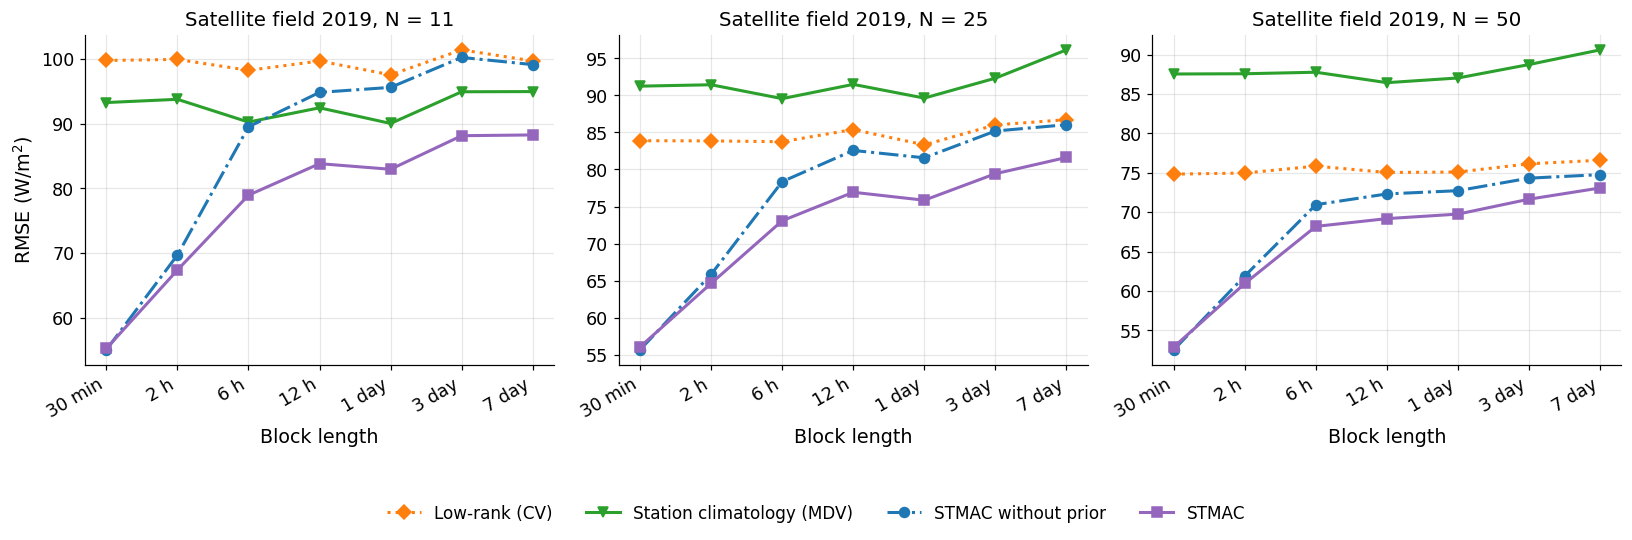

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=False)
x = np.arange(len(BLOCKS_SAT))
for ax, n in zip(axes, [11, 25, 50]):
    g = S11B[S11B.N == n].set_index("block_len").loc[[b for b, _ in BLOCKS_SAT]]
    for col, name, c, ls, mk in [("rmse_softimpute_cv", "Low-rank (CV)", "C1", ":", "D"),
                                 ("rmse_climatology", "Station climatology (MDV)", "C2", "-", "v"),
                                 ("rmse_joint_longitude", "STMAC without prior", "C0", "-.", "o"),
                                 ("rmse_anomaly_cvN", "STMAC", "C4", "-", "s")]:
        ax.plot(x, g[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.set_xticks(x); ax.set_xticklabels([l for _, l in BLOCKS_SAT], rotation=30, ha="right")
    ax.set_title(f"Satellite field 2019, N = {n}")
    ax.set_xlabel("Block length")
axes[0].set_ylabel(r"RMSE (W/m$^2$)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(RES / "E12b_E11_per_network_cv.png")
plt.show()

In [6]:
print("INTERPRETASI PEMILIHAN PER JARINGAN")
print("=" * 88)
for n in [11, 25, 50]:
    s = S11B[S11B.N == n]
    print(f"- N={n}: terpilih r = {idn(SEL[n][0], 0)}, ridge = {idn(SEL[n][1], 1)}; rata-rata lintas blok "
          f"STMAC {idn(s.rmse_anomaly_cvN.mean())}, tanpa prior {idn(s.rmse_joint_longitude.mean())}, "
          f"klimatologi {idn(s.rmse_climatology.mean())}, low-rank {idn(s.rmse_softimpute_cv.mean())} W/m2.")
    for a, nama in [("climatology", "klimatologi"), ("softimpute_cv", "low-rank"),
                    ("joint_longitude", "STMAC tanpa prior"), ("anomaly", "bobot hasil pemilihan 1999")]:
        t = T11B[(T11B.N == n) & (T11B.a == a)]
        lead, trail = t[t.mean_diff > 0], t[t.mean_diff < 0]
        print(f"  vs {nama}: unggul {len(lead)}/7 ({int((lead.p_holm < 0.05).sum())} signifikan), "
              f"tertinggal {len(trail)}/7 ({int((trail.p_holm < 0.05).sum())} signifikan), selisih "
              f"{idn(t.mean_diff.min())} sampai {idn(t.mean_diff.max())} W/m2.")
print("- Hasil ini tetap pemeriksaan struktural karena medan satelit gagal pada gate koherensi E11.")

INTERPRETASI PEMILIHAN PER JARINGAN
- N=11: terpilih r = 10, ridge = 1,0; rata-rata lintas blok STMAC 77,8, tanpa prior 86,3, klimatologi 92,8, low-rank 99,4 W/m2.
  vs klimatologi: unggul 7/7 (7 signifikan), tertinggal 0/7 (0 signifikan), selisih 6,7 sampai 38,0 W/m2.
  vs low-rank: unggul 7/7 (7 signifikan), tertinggal 0/7 (0 signifikan), selisih 11,4 sampai 44,5 W/m2.
  vs STMAC tanpa prior: unggul 6/7 (6 signifikan), tertinggal 1/7 (1 signifikan), selisih -0,2 sampai 12,6 W/m2.
  vs bobot hasil pemilihan 1999: unggul 7/7 (7 signifikan), tertinggal 0/7 (0 signifikan), selisih 0,9 sampai 22,5 W/m2.
- N=25: terpilih r = 10, ridge = 0,3; rata-rata lintas blok STMAC 72,5, tanpa prior 76,5, klimatologi 91,7, low-rank 84,7 W/m2.
  vs klimatologi: unggul 7/7 (7 signifikan), tertinggal 0/7 (0 signifikan), selisih 12,9 sampai 35,2 W/m2.
  vs low-rank: unggul 7/7 (7 signifikan), tertinggal 0/7 (0 signifikan), selisih 5,1 sampai 27,8 W/m2.
  vs STMAC tanpa prior: unggul 6/7 (6 signifikan), ter

## 3. Gambar dan tabel untuk naskah

Pada bagian ini STMAC berarti varian anomali dengan pasangan hasil validasi silang. Solver gabungan
tanpa prior ditampilkan sebagai ablasi.

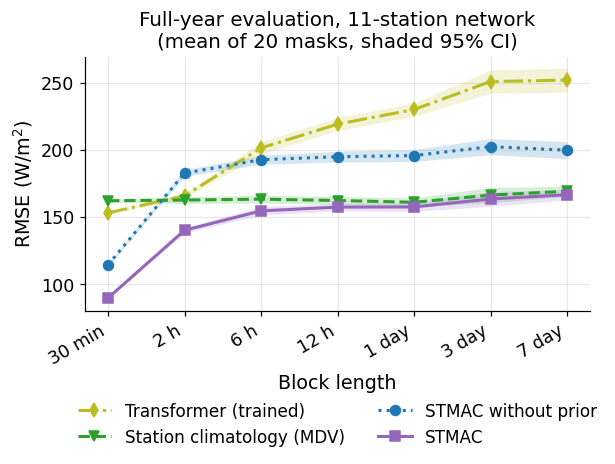

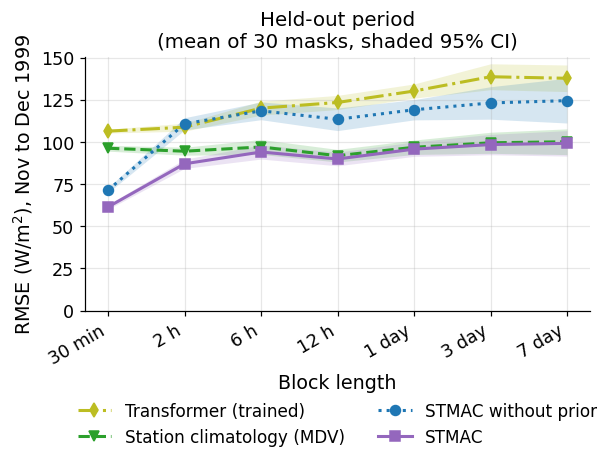

Tabel I (W/m2): setahun penuh, 20 mask; kolom _heldout: Nov sampai Des, 30 mask
        pure_temporal  climatology  transformer  joint_longitude  anomaly  transformer_heldout  climatology_heldout  anomaly_heldout
label                                                                                                                               
30 min           69.6        162.0        153.0            114.3     89.6                106.4                 96.3             61.4
2 h             113.7        162.5        165.6            182.5    140.0                108.8                 94.5             87.1
6 h             239.4        163.2        201.3            192.5    154.4                120.1                 97.1             94.1
12 h            445.4        162.1        219.0            194.8    157.2                123.4                 91.9             89.9
1 day           726.7        160.8        229.9            195.6    157.4                130.2                 96.9       

In [7]:
SA = pd.read_csv(RES / "E12_anomaly_summary.csv")
x = np.arange(len(SA))
fig, ax = plt.subplots(figsize=(5.8, 4.8))
for col, name, c, ls, mk in [("transformer", "Transformer (trained)", "C8", "-.", "d"),
                             ("climatology", "Station climatology (MDV)", "C2", "--", "v"),
                             ("joint_longitude", "STMAC without prior", "C0", ":", "o"),
                             ("anomaly", "STMAC", "C4", "-", "s")]:
    ax.plot(x, SA[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, SA[col + "_lo"], SA[col + "_hi"], color=c, alpha=0.18, lw=0)
ax.set_xticks(x); ax.set_xticklabels(SA.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$)")
ax.set_title("Full-year evaluation, 11-station network\n(mean of 20 masks, shaded 95% CI)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(RES / "E12b_fig_fullyear.png")
plt.show()

SH = pd.read_csv(RES / "E12_TF_heldout_summary.csv")
fig, ax = plt.subplots(figsize=(5.8, 4.8))
for col, name, c, ls, mk in [("transformer", "Transformer (trained)", "C8", "-.", "d"),
                             ("climatology", "Station climatology (MDV)", "C2", "--", "v"),
                             ("joint_r10", "STMAC without prior", "C0", ":", "o"),
                             ("anomaly", "STMAC", "C4", "-", "s")]:
    ax.plot(x, SH[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, SH[col + "_lo"], SH[col + "_hi"], color=c, alpha=0.18, lw=0)
ax.set_xticks(x); ax.set_xticklabels(SH.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$), Nov to Dec 1999")
ax.set_title("Held-out period\n(mean of 30 masks, shaded 95% CI)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(RES / "E12b_fig_heldout.png")
plt.show()

E7 = pd.read_csv(RES / "E12_E7J_raw.csv")
TAB1 = (SA.set_index("label")[["pure_temporal", "climatology", "transformer", "joint_longitude", "anomaly"]]
        .join(SH.set_index("label")[["transformer", "climatology", "anomaly"]], rsuffix="_heldout"))
ru.atomic_csv(TAB1.reset_index(), RES / "E12b_table1.csv")
print("Tabel I (W/m2): setahun penuh, 20 mask; kolom _heldout: Nov sampai Des, 30 mask")
print(TAB1.to_string(float_format=lambda v: f"{v:8.1f}"))